In [1]:
from google.colab import files
uploaded = files.upload()


Saving melb_data.csv to melb_data.csv


In [2]:
import csv
import random

X = []
Y = []

with open("melb_data.csv", "r") as file:
    reader = csv.DictReader(file)

    for row in reader:

        # Skip rows with missing values
        if (
            row["Rooms"] == "" or
            row["Distance"] == "" or
            row["Bathroom"] == "" or
            row["Car"] == "" or
            row["Landsize"] == "" or
            row["BuildingArea"] == "" or
            row["Price"] == "" or
            row['Bedroom2']==''
        ):
            continue

        x1 = float(row["Rooms"])
        x2 = float(row["Distance"])
        x3 = float(row["Bathroom"])
        x4 = float(row["Car"])
        x5 = float(row["Landsize"])
        x6 = float(row["BuildingArea"])
        x7 = float(row['Bedroom2'])

        y = float(row["Price"])

        X.append([x1, x2, x3, x4, x5, x6, x7])
        Y.append(y)
print(X[0:5])
print(Y[0:5])

[[2.0, 2.5, 1.0, 0.0, 156.0, 79.0, 2.0], [3.0, 2.5, 2.0, 0.0, 134.0, 150.0, 3.0], [4.0, 2.5, 1.0, 2.0, 120.0, 142.0, 3.0], [3.0, 2.5, 2.0, 0.0, 245.0, 210.0, 4.0], [2.0, 2.5, 1.0, 2.0, 256.0, 107.0, 2.0]]
[1035000.0, 1465000.0, 1600000.0, 1876000.0, 1636000.0]


In [3]:
def initialize_coefficients(num_features):

    beta=[0]*(num_features+1)

    for i in range(num_features):
        beta[i+1] = random.uniform(-0.1,0.1)

    return beta
#We initialize coefficients to small random values (better than zero)


def predict(beta,x):

    #input feature x will contain 7 features so accordingly, x[i] corresponds to value of xi+1 (in a sense that x[1] corresponds to x2, x[2] to x3 and so on)
    ans = beta[0]

    for i in range(len(x)):
        ans += beta[i+1]*x[i]

    return ans

#For evaluating error/cost, we use mean squared error

def compute_cost(X,Y,beta):

    num_points = len(X)
    cost=0
    #num_points denotes the number of input points across which we will evaluate the cost
    for i in range(num_points):
        y_pred = predict(beta, X[i])
        y_true = Y[i]
        cost+=(y_pred-y_true)**2
    return cost/num_points


def gradsf(X,Y,beta):
    n = len(X)
    #n is number of data points
    grads=[0]*(len(beta))
    for i in range(n):
        #This is for dj/dbeta0
        y_pred_i = predict(beta,X[i])
        y_true_i = Y[i]
        grads[0] += 2/n * (y_pred_i-y_true_i)
        #This is for beta1, beta2, ..., beta7
        for j in range(1,len(beta)):
            grads[j] += 2/n * (y_pred_i-y_true_i)*(X[i][j-1])

    return grads
#The above grads is an array containing dj/db0, dj/db1, ..., dj/db7

def update_parameters(X,Y,beta, learning_rate,num_iterations=20000,print_cost=False):
    n = len(beta)
    costs_loop = []
    for iter in range(1,num_iterations+1):
        grads = gradsf(X,Y,beta)
        for i in range(n):
            beta[i] = beta[i] - grads[i]*learning_rate
        cost = compute_cost(X,Y,beta)

        costs_loop.append(cost)
        if print_cost and iter%1000==0:
            print("Cost after iteration %d is: %f" % (iter, cost))
    return beta, costs_loop
import time
def train_pricing_model(X_train,Y_train,print_cost=False,learning_rate=0.001,num_iterations=20000):
    tic = time.time()
    beta = initialize_coefficients(len(X_train[0]))
    beta, costs_loop = update_parameters(X_train,Y_train,beta,learning_rate,num_iterations,print_cost)
    toc = time.time()
    return beta,toc-tic,costs_loop




In [4]:
import copy
combined=list(zip(X,Y))
random.shuffle(combined)

X[:],Y[:]=zip(*combined)

X=list(X)
Y=list(Y)
X_orig = copy.deepcopy(X)
Y_orig = copy.deepcopy(Y)

split = int(0.8*len(X))
X_train_orig = X_orig[:split]
X_test_orig = X_orig[split:]
Y_train_orig = Y_orig[:split]
Y_test_orig = Y_orig[split:]
X_train = X[:split]
Y_train = Y[:split]
X_test = X[split:]
Y_test = Y[split:]



In [5]:
num_features = len(X_train[0])
for j in range(num_features):
    column=[]
    for i in range(len(X_train)):
        column.append(X_train[i][j])
    mean = sum(column)/len(column)
    var=0
    for val in column:
        var+=(val-mean)**2
    var = var/len(column)
    stddev = var**0.5
    for i in range(len(X_train)):
        X_train[i][j]=(X_train[i][j]-mean)/stddev
    for i in range(len(X_test)):
      X_test[i][j] = (X_test[i][j]-mean)/stddev
Y_mean = sum(Y_train)/len(Y_train)
Y_var = 0
for val in Y_train:
    Y_var+= (val-Y_mean)**2
Y_var = Y_var/len(Y_train)
Y_stddev = Y_var**0.5
for i in range(len(Y_train)):
    Y_train[i] = (Y_train[i]-Y_mean)/Y_stddev


In [6]:
beta, training_time_loop, costs_loop = train_pricing_model(X_train,Y_train,print_cost=True,learning_rate=0.003,num_iterations = 30000)
Y_pred = []
num_points = len(X_test)
for i in range(num_points):
  y_pred = predict(beta,X_test[i])
  Y_pred.append(y_pred*Y_stddev +Y_mean)


Cost after iteration 1000 is: 0.578353
Cost after iteration 2000 is: 0.577465
Cost after iteration 3000 is: 0.576969
Cost after iteration 4000 is: 0.576687
Cost after iteration 5000 is: 0.576526
Cost after iteration 6000 is: 0.576435
Cost after iteration 7000 is: 0.576383
Cost after iteration 8000 is: 0.576354
Cost after iteration 9000 is: 0.576337
Cost after iteration 10000 is: 0.576327
Cost after iteration 11000 is: 0.576322
Cost after iteration 12000 is: 0.576319
Cost after iteration 13000 is: 0.576317
Cost after iteration 14000 is: 0.576316
Cost after iteration 15000 is: 0.576316
Cost after iteration 16000 is: 0.576315
Cost after iteration 17000 is: 0.576315
Cost after iteration 18000 is: 0.576315
Cost after iteration 19000 is: 0.576315
Cost after iteration 20000 is: 0.576315
Cost after iteration 21000 is: 0.576315
Cost after iteration 22000 is: 0.576315
Cost after iteration 23000 is: 0.576315
Cost after iteration 24000 is: 0.576315
Cost after iteration 25000 is: 0.576315
Cost afte

In [7]:
mae_loop=0
mse_loop=0
length_test=len(Y_pred)
for i in range(length_test):
    error=Y_pred[i]-Y_test[i]
    mae_loop+=abs(error)
    mse_loop+=error**2
mae_loop=mae_loop/length_test
mse_loop=mse_loop/length_test
rmse_loop=mse_loop**0.5

num=mse_loop*length_test
Y_test_mean=sum(Y_test)/len(Y_test)
denom=0
for val in Y_test:
    denom+=(val-Y_test_mean)**2
r2_score_loop=1-(num/denom)

print('RMSE value obtained on test set is:',rmse_loop)
print('Mean Absolute Error obtained on test set is:',mae_loop)
print('R2 Score is:',r2_score_loop)
print("Training time taken:", training_time_loop)

RMSE value obtained on test set is: 541749.593501467
Mean Absolute Error obtained on test set is: 350956.30936980713
R2 Score is: 0.4074879715619324
Training time taken: 431.5272512435913


## Vectorized Implementation

In [22]:
import numpy as np
import time
import csv

def initialize_coefficients_vector(num_features):
    beta = np.random.uniform(-0.1, 0.1, size=num_features)
    return beta

def predict_vector(X, beta):
    return np.dot(X, beta)

def compute_cost_vector(X, Y, beta):
    n = len(X)
    predictions = predict_vector(X, beta)
    errors = predictions - Y
    cost = 1/n * np.sum(errors ** 2)

    return cost

def compute_gradients(X, Y, beta):
    n = len(X)
    predictions = predict_vector(X, beta)
    errors = predictions - Y
    grads = (2 / n) * np.dot(X.T, errors)
    return grads

def train_linear_regression(X,Y,learning_rate=0.001,num_iterations=30000,print_cost=True):
    beta = initialize_coefficients_vector(X.shape[1])
    start_time = time.time()
    costs_vector = []
    for iteration in range(num_iterations):
        grads = compute_gradients(X, Y, beta)
        beta = beta - learning_rate * grads
        cost = compute_cost_vector(X, Y, beta)
        costs_vector.append(cost)
        if print_cost and iteration % 1000 == 0:
            print(f"Cost after iteration {iteration} is: {cost}")

    end_time = time.time()
    training_time = end_time - start_time
    print("\nTraining Time:", training_time, "seconds")
    return beta, training_time,costs_vector



In [14]:
from google.colab import files
uploaded = files.upload()


In [23]:
import csv
import numpy as np

X = []
Y = []

with open("melb_data.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        if (
            row["Rooms"] == "" or
            row["Distance"] == "" or
            row["Bathroom"] == "" or
            row["Car"] == "" or
            row["Landsize"] == "" or
            row["BuildingArea"] == "" or
            row["Price"] == "" or
            row["Bedroom2"] == ""
        ):
            continue

        x1 = float(row["Rooms"])
        x2 = float(row["Distance"])
        x3 = float(row["Bathroom"])
        x4 = float(row["Car"])
        x5 = float(row["Landsize"])
        x6 = float(row["BuildingArea"])
        x7 = float(row["Bedroom2"])

        y = float(row["Price"])

        X.append([x1, x2, x3, x4, x5, x6, x7])
        Y.append(y)
X = np.array(X)
Y = np.array(Y)


In [24]:
import copy
X_orig = copy.deepcopy(X)
Y_orig = copy.deepcopy(Y)
#Following shuffling code is LLM generated

indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

In [25]:
split = int(0.8 * len(X))
X_train = X[:split]
Y_train = Y[:split]
X_test = X[split:]
Y_test = Y[split:]

X_mean = np.mean(X_train,axis=0)
X_std = np.std(X_train,axis=0)

X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

Y_mean = np.mean(Y_train)
Y_std = np.std(Y_train)
Y_train = (Y_train - Y_mean) / Y_std
#Following addition of bias term is LLM generated
ones_train = np.ones((X_train.shape[0],1))
ones_test = np.ones((X_test.shape[0],1))

X_train = np.hstack((ones_train,X_train))
X_test = np.hstack((ones_test,X_test))
#here, we have normalised xtrain, xtest, and ytrain

In [28]:
beta, training_time_vector,costs_vector = train_linear_regression(X_train,Y_train,learning_rate=0.003,num_iterations=30000,print_cost=True)
Y_pred = predict_vector(X_test, beta) * Y_std + Y_mean
Y_true = Y_test
mae_vector = np.mean(np.abs(Y_pred - Y_true))
mse_vector = np.mean((Y_pred - Y_true) ** 2)
rmse_vector = np.sqrt(mse_vector)
ss_res = np.sum((Y_true - Y_pred) ** 2)
ss_tot = np.sum((Y_true - np.mean(Y_true)) ** 2)
r2_score_vector = 1 - (ss_res / ss_tot)

print("MAE:", mae_vector)
print("MSE:", mse_vector)
print("RMSE:", rmse_vector)
print("R2:", r2_score_vector)


Cost after iteration 0 is: 1.144336524197665
Cost after iteration 1000 is: 0.5825235442339494
Cost after iteration 2000 is: 0.5819010700838564
Cost after iteration 3000 is: 0.5815239132012173
Cost after iteration 4000 is: 0.5812922587970345
Cost after iteration 5000 is: 0.5811499712657185
Cost after iteration 6000 is: 0.5810625749401833
Cost after iteration 7000 is: 0.5810088940754452
Cost after iteration 8000 is: 0.5809759220343278
Cost after iteration 9000 is: 0.5809556698364403
Cost after iteration 10000 is: 0.5809432304634027
Cost after iteration 11000 is: 0.5809355899098969
Cost after iteration 12000 is: 0.5809308969034488
Cost after iteration 13000 is: 0.5809280143492589
Cost after iteration 14000 is: 0.5809262438171383
Cost after iteration 15000 is: 0.5809251563149501
Cost after iteration 16000 is: 0.5809244883457018
Cost after iteration 17000 is: 0.5809240780633855
Cost after iteration 18000 is: 0.5809238260584026
Cost after iteration 19000 is: 0.5809236712710552
Cost after ite

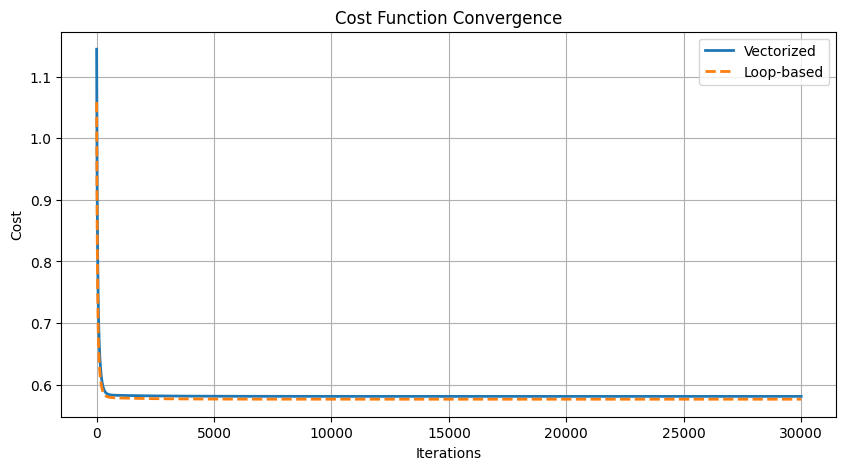

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(costs_vector, label="Vectorized", linewidth=2)
plt.plot(costs_loop, label="Loop-based", linewidth=2, linestyle="--")

plt.title("Cost Function Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)

plt.show()

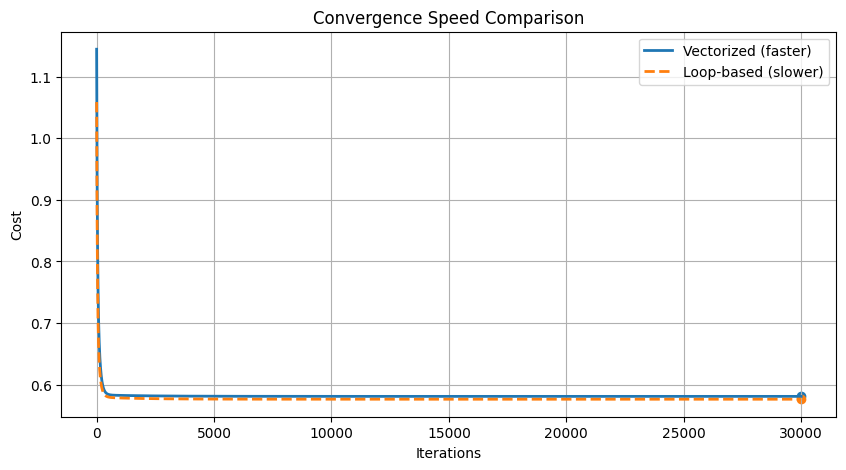

In [31]:
plt.figure(figsize=(10,5))

plt.plot(costs_vector, label="Vectorized (faster)", linewidth=2)
plt.plot(costs_loop, label="Loop-based (slower)", linewidth=2, linestyle="--")

plt.scatter(len(costs_vector)-1, costs_vector[-1])
plt.scatter(len(costs_loop)-1, costs_loop[-1])

plt.title("Convergence Speed Comparison")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)

plt.show()


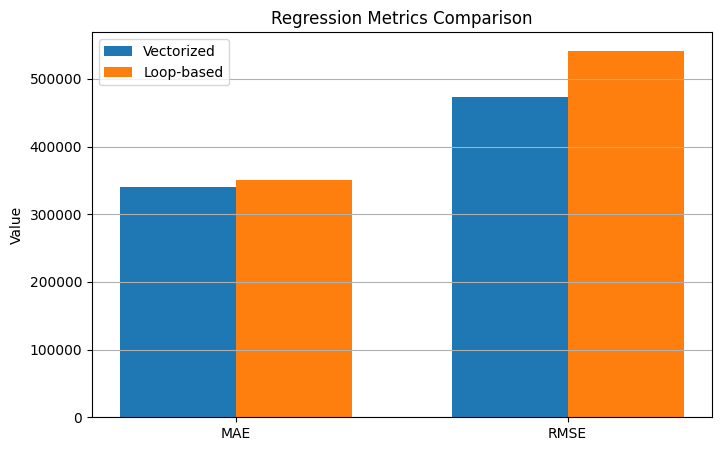

In [34]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["MAE", "RMSE"]

vectorized_metrics = [mae_vector, rmse_vector]
loop_metrics = [mae_loop, rmse_loop]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, vectorized_metrics, width, label="Vectorized")
plt.bar(x + width/2, loop_metrics, width, label="Loop-based")

plt.xticks(x, metrics)
plt.title("Regression Metrics Comparison")
plt.ylabel("Value")
plt.legend()
plt.grid(axis="y")

plt.show()
#Help from LLM was taken for plotting the following graph

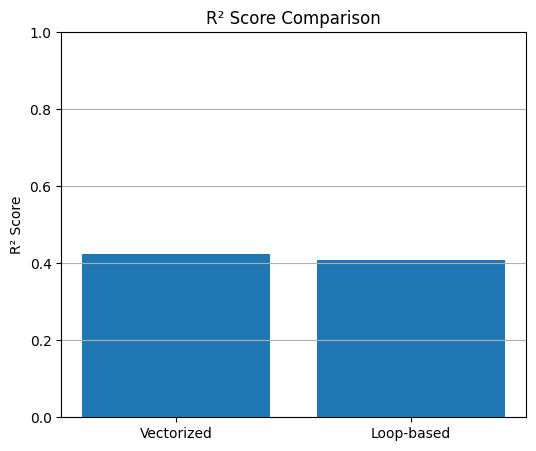

In [38]:
import matplotlib.pyplot as plt

methods = ["Vectorized", "Loop-based"]
r2_scores = [r2_score_vector, r2_score_loop]

plt.figure(figsize=(6,5))

plt.bar(methods, r2_scores)

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.grid(axis="y")

plt.show()

In [39]:
print("Training time for vectorized implementation is:",training_time_vector,"seconds")
print("Training time for looping implementation is", training_time_loop,"seconds")

Training time for vectorized implementation is: 1.9950506687164307 seconds
Training time for looping implementation is 431.5272512435913 seconds


In [42]:
print('RMSE value obtained on test set with loop implementation is:',rmse_loop)
print('Mean Absolute Error obtained on test set with loop implementation is:',mae_loop)
print('R2 Score with loop implementation is:',r2_score_loop)
print("\n")
print('RMSE value obtained on test set with vectorized implementation is:',rmse_vector)
print('Mean Absolute Error obtained on test set with vectorized implementation is:',mae_vector)
print('R2 Score with vectorized implementation is:',r2_score_vector)

RMSE value obtained on test set with loop implementation is: 541749.593501467
Mean Absolute Error obtained on test set with loop implementation is: 350956.30936980713
R2 Score with loop implementation is: 0.4074879715619324


RMSE value obtained on test set with vectorized implementation is: 472480.66805223294
Mean Absolute Error obtained on test set with vectorized implementation is: 340134.5275709414
R2 Score with vectorized implementation is: 0.42453553997617155
